# caricamento dataset e DataAugmentation

In [1]:
import pandas as pd
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset, random_split

# Prepariamo le trasformazioni richieste
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=10),
    # Le immagini sono 32x32, quindi 5pixel su 32 
    transforms.RandomAffine(degrees=0, translate=(5/32, 5/32)),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

eval_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

# Caricamento DATASETS

full_train_aug = torchvision.datasets.CIFAR10(root='./data', download=True, train=True, transform=train_transforms)
full_train_eval = torchvision.datasets.CIFAR10(root='./data', download=False, train=True, transform=eval_transforms)
test_set = torchvision.datasets.CIFAR10(root='./data', download=False, train=False, transform=eval_transforms)

generatore = torch.Generator().manual_seed(42)

n_total = len(full_train_aug) # 50000

train_size = int(0.9*n_total)
val_size = n_total - train_size

#Divido casualmente gli indici dei due set
train_idx, val_idx = random_split(range(n_total), [train_size,val_size])

# Creo un Subset tramite gli indici estratti => 90% train set, 10% val set
train_set = Subset(full_train_aug, indices=train_idx.indices)
val_set = Subset(full_train_eval, indices=val_idx.indices)


print("Dati caricati con successo")
print(f"Train: {len(train_set)}")
print(f"Val: {len(val_set)}")
print(f"Test: {len(test_set)}")

Dati caricati con successo
Train: 45000
Val: 5000
Test: 10000


# Creazione classificatore con Gradient boosting

Implementare un classificatore dei punti del data set processato al punto 1, 
utilizzando  un  algoritmo  di  Gradient  Boosting  con  la  seguente  griglia  di 
ricerca, usando una cross-validation a 10 fold: 
- Learning rate: 0.01, 0.1, 0.2 
- N. stimatori: 50, 100, 200 
- Min. campioni per foglia: 10, 20, 50
 
Stampare l’accuracy del miglior modello in addestramento e in predizione.

In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np
from sklearn.decomposition import PCA

def dataset_to_numpy(dataset, max_samples=1000):
    images=[]
    labels=[]
    for i in range(min(max_samples, len(dataset))):
        img,label=dataset[i]
        images.append(img.numpy().flatten())
        labels.append(label)
    return np.array(images), np.array(labels)

print("Estrazione dati grezzi")

X_train_raw, y_train_gb=dataset_to_numpy(train_set, 1500)
X_test_raw, y_test_gb=dataset_to_numpy(test_set, 500)
pca = PCA(n_components=50, random_state=42)
X_train_gb=pca.fit_transform(X_train_raw)
X_test_gb=pca.transform(X_test_raw)

print(f"Dataset originale: {X_train_raw.shape}")
print(f"Dataset dopo PCA: {X_train_gb.shape}")

param_grid={
    'learning_rate' : [0.01, 0.1, 0.2],
    'n_estimators' : [50,100],
    'min_samples_leaf' : [10,20,50]
}

gbc=GradientBoostingClassifier()
grid=GridSearchCV(estimator=gbc, param_grid=param_grid, cv=10, scoring='accuracy', n_jobs=2)
grid.fit(X_train_gb, y_train_gb)
best_model = grid.best_estimator_

acc_train = grid.score(X_train_gb,y_train_gb)
acc_test = grid.score(X_test_gb,y_test_gb)

print(f"Best_model : {best_model}")
print(f"Accuracy train: {acc_train}")
print(f"Accuracy test: {acc_test}")




Estrazione dati grezzi
Dataset originale: (1500, 3072)
Dataset dopo PCA: (1500, 50)
Best_model : GradientBoostingClassifier(learning_rate=0.2, min_samples_leaf=10)
Accuracy train: 1.0
Accuracy test: 0.232


# Creazione rete neurale convoluzionale


In [3]:
import torchnn as tnn 
import torch
from torch import nn
import torch.nn.functional as F

class CIFAR10net(nn.Module):
    def __init__(self):
        super().__init__()
        # Primo layer convoluzionale
        self.conv1 = nn.Conv2d(3,32, kernel_size=3, padding=1)
        # Secondo layer convoluzionale con stride, raddoppiamo la dimensionalita'
        self.conv2 = nn.Conv2d(32,64, kernel_size=3, stride=2)
        # max pooling 
        self.pool = nn.MaxPool2d(kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64,128, kernel_size=3, padding=1)

        # Layer finali fully-connected
        self.fc1=nn.Linear(128, 256)
        self.dropout=nn.Dropout(0.2)
        self.fc2=nn.Linear(256,10)

    def forward(self, x):
        x=self.pool(F.relu(self.conv1(x)))
        x=self.pool(F.relu(self.conv2(x)))
        x=self.pool(F.relu(self.conv3(x)))
        # Flatten prima di passare ai layer fully connected
        x=x.view(x.size(0), -1)
        x=F.relu(self.fc1(x))
        x=self.dropout(x)
        x=self.fc2(x)
        return x

    print("Modello caricato!")
    

Modello caricato!


Dispositivo in uso: cuda
Shape e tipo dei campioni: torch.Size([64, 3, 32, 32]), torch.float32
Shape e tipo delle etichette: torch.Size([64]) torch.int64


Epoch    1: 100%|██████████| 704/704 [00:16<00:00, 42.46it/s]


Train loss: 2.0885
Validation loss: 2.0036
Test loss: 1.9921 Accuracy:   0.26
Metrics:



Epoch    2: 100%|██████████| 704/704 [00:16<00:00, 43.39it/s]


Train loss: 1.7335
Validation loss: 1.7247
Test loss: 1.7271 Accuracy:   0.37
Metrics:



...

Train loss: 1.0023
Validation loss: 0.9859
Test loss: 0.9796 Accuracy:   0.65
Metrics:



Epoch   29: 100%|██████████| 704/704 [00:17<00:00, 41.26it/s] 


Train loss: 0.9973
Validation loss: 0.9558
Test loss: 0.9486 Accuracy:   0.65
Metrics:



Epoch   30: 100%|██████████| 704/704 [00:17<00:00, 39.67it/s]


Train loss: 0.9929
Validation loss: 0.9972
Test loss: 0.9870 Accuracy:   0.65
Metrics:



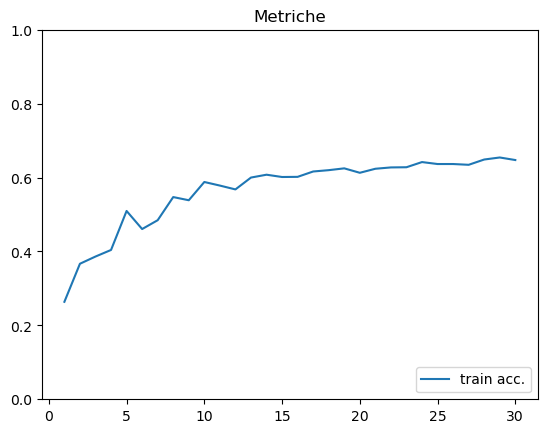

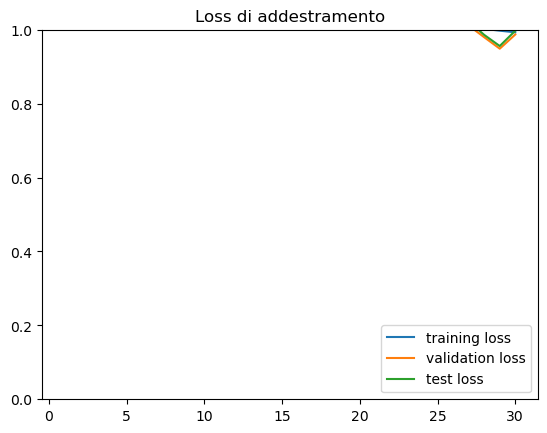

In [4]:
import torch.optim as optim

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo in uso: {device}")

model=CIFAR10net().to(device)

optimizer=optim.SGD(model.parameters(), nesterov=True, lr=0.01, momentum=0.9)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer=optimizer, gamma=0.95)
early_stopping = tnn.EarlyStopping(patience=5, min_delta=0.01)

train_loader, val_loader, test_loader= tnn.make_dataloaders(train_set, val_set, test_set, batch=64)

loss_fn = nn.CrossEntropyLoss()

train_loss, val_loss, test_loss, accuracy, test_metrics = tnn.train_test(
    model=model,
    optimizer=optimizer,
    device=device,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    epochs=30,
    early_stopping=early_stopping,
    val_dataloader=val_loader,
    scheduler=scheduler,
    train_loss_fn=loss_fn,
    test_loss_fn=loss_fn,
    metrics=[],
    average='macro'
)
tnn.displayMetrics(accuracy, test_metrics)
tnn.displayLosses(train_loss, val_loss, test_loss)
torch.save(model.state_dict(), 'best_model_4.pt')



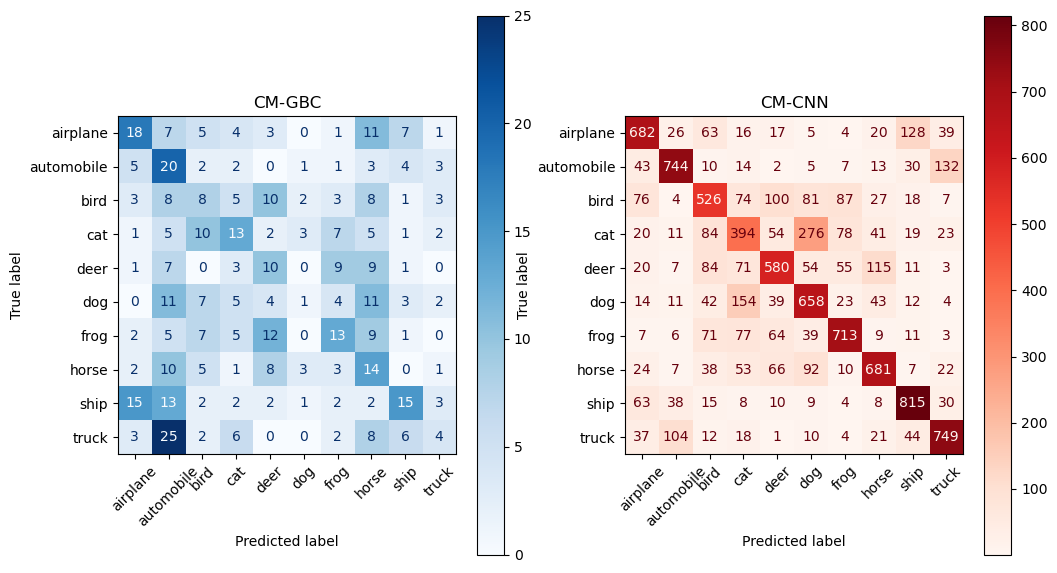

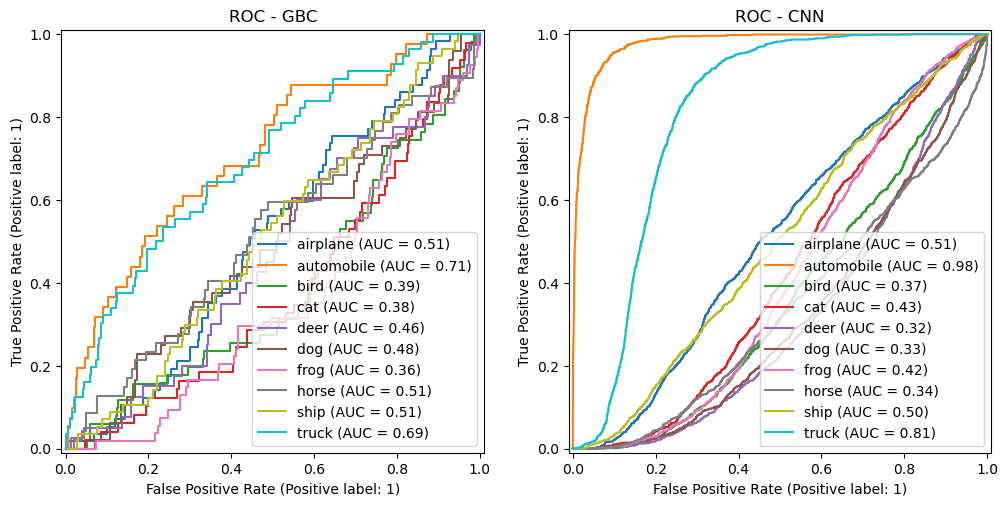

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer

model.eval()
nn_true, nn_pred, nn_prob = [],[],[]
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits=model(X_batch)
        prob=torch.softmax(logits, dim=1)
        pred=torch.argmax(prob, dim=1)

        nn_true.extend(y_batch.cpu().numpy())
        nn_pred.extend(pred.cpu().numpy()) 
        nn_prob.extend(prob.cpu().numpy()) 

nn_true=np.array(nn_true)
nn_pred=np.array(nn_pred)
nn_prob=np.array(nn_prob)

gbc_pred = grid.predict(X_test_gb)
gbc_prob = grid.predict_proba(X_test_gb)

class_name = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig, ax = plt.subplots(1,2, figsize=(12,7))
ConfusionMatrixDisplay.from_predictions(y_test_gb, gbc_pred, display_labels=class_name, xticks_rotation=45, ax=ax[0], cmap='Blues')
ax[0].set_title('CM-GBC')
ConfusionMatrixDisplay.from_predictions(nn_true, nn_pred, display_labels=class_name, xticks_rotation=45, ax=ax[1], cmap='Reds')
ax[1].set_title('CM-CNN')
plt.show()

# Dobbiamo calcolare Auc e Roc, ma bisogna tenere conto che questa e' classificazione MULTICLASSE e non binaria
# Dobbiamo fare un LabelBinarizer fissando y_test_gb

lb=LabelBinarizer().fit(y_test_gb)
y_test_gb_bin = lb.transform(y_test_gb)
nn_true_bin = lb.transform(nn_true)

fig, ax = plt.subplots(1,2, figsize=(12,7))
for i, classes in enumerate(class_name):
    # Per ciascuna classe stampiamo AuC
    RocCurveDisplay.from_predictions(y_test_gb_bin[:, i], gbc_prob[:, 1], name=classes, ax=ax[0])
    ax[0].set_title('ROC - GBC')
for i, classes in enumerate(class_name):
    # Per ciascuna classe stampiamo AuC
    RocCurveDisplay.from_predictions(nn_true_bin[:, i], nn_prob[:, 1], name=classes, ax=ax[1])
    ax[1].set_title('ROC - CNN')


